# Drone Object Detection with YOLO
This notebook builds a professional end-to-end workflow for drone object detection using YOLO-format labels. It covers environment setup, dataset inspection, annotation validation, visualization, multi-model training, evaluation, model comparison, inference, and error analysis.

## Notebook Roadmap
The workflow is organized into five stages:
1. Set up the environment and project configuration.
2. Inspect and validate the YOLO dataset.
3. Visualize annotations and recommend augmentations.
4. Train and compare multiple Ultralytics models.
5. Run prediction demos and perform error analysis.

In [13]:
# Uncomment the next line if you need to install packages inside this notebook.
# %pip install -q ultralytics opencv-python matplotlib numpy pandas tqdm PyYAML scikit-learn mlflow

import math
import random
import shutil
import time
import warnings
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import Markdown, display
from tqdm.auto import tqdm
from ultralytics import YOLO

try:
    import mlflow
    MLFLOW_AVAILABLE = True
except ImportError:
    mlflow = None
    MLFLOW_AVAILABLE = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print(f'PyTorch version: {torch.__version__}')
print(f'Ultralytics available: {YOLO is not None}')
print(f'MLflow available: {MLFLOW_AVAILABLE}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device: {torch.cuda.get_device_name(0)}')
else:
    print('GPU not detected. Training will run on CPU unless a CUDA device is enabled.')

PyTorch version: 2.11.0+cu128
Ultralytics available: True
MLflow available: True
CUDA available: True
GPU device: NVIDIA GeForce RTX 3050 Laptop GPU


## Project Configuration
These top-level variables keep the notebook reusable and avoid hardcoded paths throughout the workflow. The notebook targets the existing `dl_venv` environment and the unified YOLO dataset created earlier.

In [15]:
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data' / 'merged_drone_dataset_yolo'
YAML_PATH = DATA_DIR / 'dataset.yaml'
PROJECT_NAME = 'drone_object_detection'
IMAGE_SIZE = 640
EPOCHS = 50
BATCH_SIZE = 16
PATIENCE = 20
CONF_THRESHOLD = 0.25
SEED = 42
WORKERS = 0
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
SPLITS = ('train', 'val', 'test')
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
RUNS_ROOT = ROOT / 'runs'
PREDICTION_DIR = ROOT / 'outputs' / 'predictions'
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)

try:
    torch.manual_seed(SEED)
except Exception as seed_error:
    print(f'Torch seed setup skipped: {seed_error}')
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass

print(f'Data directory: {DATA_DIR}')
print(f'Dataset YAML path: {YAML_PATH}')
print(f'Device: {DEVICE}')

Torch seed setup skipped: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Data directory: d:\college\semester6\deep_learning\drone_detection\data\merged_drone_dataset_yolo
Dataset YAML path: d:\college\semester6\deep_learning\drone_detection\data\merged_drone_dataset_yolo\dataset.yaml
Device: 0


## Dataset Utilities
The helper functions below read split folders, parse YOLO labels, convert normalized boxes to pixel coordinates, and create `dataset.yaml` if it is missing or incomplete.

In [3]:
def image_dir(split: str) -> Path:
    return DATA_DIR / split / 'images'

def label_dir(split: str) -> Path:
    return DATA_DIR / split / 'labels'

def list_images(split: str):
    return sorted(path for path in image_dir(split).glob('*') if path.suffix.lower() in IMAGE_EXTENSIONS)

def label_path_for_image(image_path: Path, split: str) -> Path:
    return label_dir(split) / f'{image_path.stem}.txt'

def read_image_rgb(image_path: Path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        return None
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def read_image_bgr(image_path: Path):
    return cv2.imread(str(image_path))

def parse_yolo_label_file(label_path: Path):
    boxes = []
    parse_errors = []
    if not label_path.exists():
        return boxes, parse_errors

    raw_text = label_path.read_text(encoding='utf-8').strip()
    if not raw_text:
        return boxes, parse_errors

    for line_number, line in enumerate(raw_text.splitlines(), start=1):
        parts = line.split()
        if len(parts) != 5:
            parse_errors.append({
                'label_path': str(label_path),
                'line_number': line_number,
                'issue': 'Expected exactly 5 values in YOLO label line.',
                'raw_line': line,
            })
            continue

        try:
            class_id = int(float(parts[0]))
            x_center, y_center, width, height = map(float, parts[1:])
        except ValueError:
            parse_errors.append({
                'label_path': str(label_path),
                'line_number': line_number,
                'issue': 'Could not parse numeric YOLO values.',
                'raw_line': line,
            })
            continue

        boxes.append({
            'class_id': class_id,
            'x_center': x_center,
            'y_center': y_center,
            'width': width,
            'height': height,
            'line_number': line_number,
        })

    return boxes, parse_errors

def yolo_to_xyxy(box, image_width: int, image_height: int):
    x_center_px = box['x_center'] * image_width
    y_center_px = box['y_center'] * image_height
    width_px = box['width'] * image_width
    height_px = box['height'] * image_height
    x1 = max(0, int(round(x_center_px - width_px / 2)))
    y1 = max(0, int(round(y_center_px - height_px / 2)))
    x2 = min(image_width - 1, int(round(x_center_px + width_px / 2)))
    y2 = min(image_height - 1, int(round(y_center_px + height_px / 2)))
    return x1, y1, x2, y2

def ensure_dataset_yaml(yaml_path: Path, data_dir: Path, class_names=None):
    if class_names is None:
        class_names = ['drone']

    default_yaml = {
        'path': data_dir.as_posix(),
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'names': {index: name for index, name in enumerate(class_names)},
    }

    if not yaml_path.exists():
        yaml_path.write_text(yaml.safe_dump(default_yaml, sort_keys=False), encoding='utf-8')
        return default_yaml, True

    yaml_data = yaml.safe_load(yaml_path.read_text(encoding='utf-8')) or {}
    updated = False
    for key, value in default_yaml.items():
        if key not in yaml_data or yaml_data[key] in (None, ''):
            yaml_data[key] = value
            updated = True

    yaml_data['path'] = data_dir.as_posix()
    if updated:
        yaml_path.write_text(yaml.safe_dump(yaml_data, sort_keys=False), encoding='utf-8')
    return yaml_data, updated

dataset_yaml, yaml_created_or_updated = ensure_dataset_yaml(YAML_PATH, DATA_DIR)
display(pd.DataFrame([dataset_yaml]))
print(f'dataset.yaml created or updated: {yaml_created_or_updated}')

,path,train,val,test,names
0,d:/college/semester6/deep_learning/drone_detec...,train/images,val/images,test/images,{0: 'drone'}


dataset.yaml created or updated: False


## Dataset Inspection
This section scans every split, verifies image-label pairing, parses YOLO annotations, counts drone instances, and prepares summary tables used later for visualization and validation.

In [4]:
image_records = []
box_records = []
parse_issue_records = []

for split in SPLITS:
    for image_path in tqdm(list_images(split), desc=f'Scanning {split}', leave=False):
        image_bgr = read_image_bgr(image_path)
        label_path = label_path_for_image(image_path, split)
        label_exists = label_path.exists()
        empty_label = False
        boxes = []
        parse_errors = []

        if label_exists:
            raw_content = label_path.read_text(encoding='utf-8').strip()
            empty_label = raw_content == ''
            boxes, parse_errors = parse_yolo_label_file(label_path)
            parse_issue_records.extend(parse_errors)

        if image_bgr is None:
            image_height = np.nan
            image_width = np.nan
            readable = False
        else:
            image_height, image_width = image_bgr.shape[:2]
            readable = True

        image_records.append({
            'split': split,
            'image_path': str(image_path),
            'image_name': image_path.name,
            'stem': image_path.stem,
            'label_path': str(label_path),
            'label_exists': label_exists,
            'empty_label': empty_label,
            'image_readable': readable,
            'image_width': image_width,
            'image_height': image_height,
            'object_count': len(boxes),
        })

        for box in boxes:
            x_min_norm = box['x_center'] - box['width'] / 2
            y_min_norm = box['y_center'] - box['height'] / 2
            x_max_norm = box['x_center'] + box['width'] / 2
            y_max_norm = box['y_center'] + box['height'] / 2

            width_px = box['width'] * image_width if readable else np.nan
            height_px = box['height'] * image_height if readable else np.nan

            box_records.append({
                'split': split,
                'stem': image_path.stem,
                'image_name': image_path.name,
                'class_id': box['class_id'],
                'class_name': 'drone' if box['class_id'] == 0 else f'class_{box["class_id"]}',
                'x_center': box['x_center'],
                'y_center': box['y_center'],
                'width': box['width'],
                'height': box['height'],
                'area': box['width'] * box['height'],
                'width_px': width_px,
                'height_px': height_px,
                'area_px': width_px * height_px if readable else np.nan,
                'x_min_norm': x_min_norm,
                'y_min_norm': y_min_norm,
                'x_max_norm': x_max_norm,
                'y_max_norm': y_max_norm,
                'line_number': box['line_number'],
            })

image_df = pd.DataFrame(image_records)
box_df = pd.DataFrame(box_records)
parse_issues_df = pd.DataFrame(parse_issue_records)

inspection_summary = pd.DataFrame([
    {
        'total_images': int(len(image_df)),
        'total_labels_found': int(image_df['label_exists'].sum()),
        'missing_labels': int((~image_df['label_exists']).sum()),
        'empty_labels': int(image_df['empty_label'].sum()),
        'unreadable_images': int((~image_df['image_readable']).sum()),
        'drone_instances': int(len(box_df)),
    }
])

split_summary = (
    image_df.groupby('split')
    .agg(
        images=('image_name', 'count'),
        labels_found=('label_exists', 'sum'),
        missing_labels=('label_exists', lambda values: int((~values).sum())),
        empty_labels=('empty_label', 'sum'),
        unreadable_images=('image_readable', lambda values: int((~values).sum())),
        drone_instances=('object_count', 'sum'),
    )
    .reset_index()
 )

display(inspection_summary)
display(split_summary)
display(image_df.head())
if not parse_issues_df.empty:
    display(parse_issues_df.head())
else:
    print('No YOLO parsing issues were found during dataset inspection.')

Scanning train:   0%|          | 0/1021 [00:00<?, ?it/s]

,total_images,total_labels_found,missing_labels,empty_labels,unreadable_images,drone_instances
0,1460,1460,0,0,0,1587


,split,images,labels_found,missing_labels,empty_labels,unreadable_images,drone_instances
0,test,220,220,0,0,0,234
1,train,1021,1021,0,0,0,1099
2,val,219,219,0,0,0,254


,split,image_path,image_name,stem,label_path,label_exists,empty_label,image_readable,image_width,image_height,object_count
0,train,d:\college\semester6\deep_learning\drone_detec...,0001.jpg,0001,d:\college\semester6\deep_learning\drone_detec...,True,False,True,900,400,6
1,train,d:\college\semester6\deep_learning\drone_detec...,0004.jpg,0004,d:\college\semester6\deep_learning\drone_detec...,True,False,True,2000,1334,1
2,train,d:\college\semester6\deep_learning\drone_detec...,0005.jpg,0005,d:\college\semester6\deep_learning\drone_detec...,True,False,True,2000,1333,1
3,train,d:\college\semester6\deep_learning\drone_detec...,0007.jpg,0007,d:\college\semester6\deep_learning\drone_detec...,True,False,True,820,459,1
4,train,d:\college\semester6\deep_learning\drone_detec...,0010.jpg,0010,d:\college\semester6\deep_learning\drone_detec...,True,False,True,810,539,2


No YOLO parsing issues were found during dataset inspection.


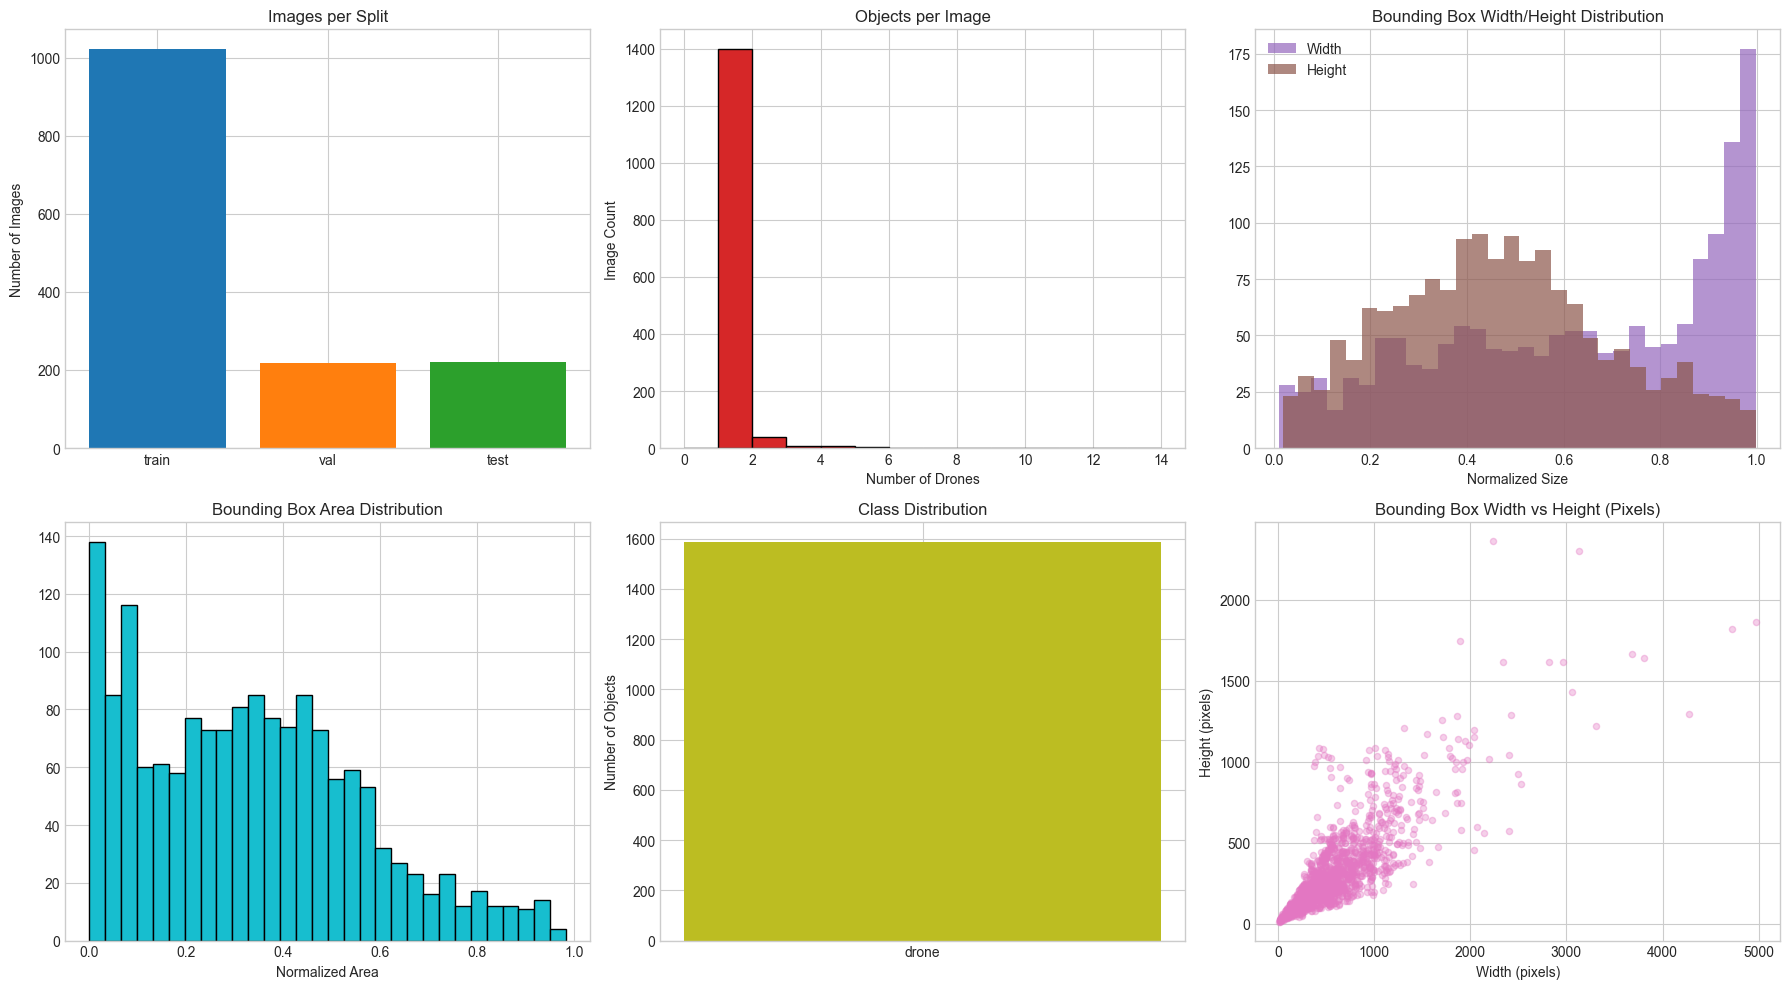

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

images_per_split = image_df.groupby('split').size().reindex(SPLITS, fill_value=0)
axes[0, 0].bar(images_per_split.index, images_per_split.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_title('Images per Split')
axes[0, 0].set_ylabel('Number of Images')

axes[0, 1].hist(image_df['object_count'], bins=range(0, int(image_df['object_count'].max()) + 2), color='#d62728', edgecolor='black')
axes[0, 1].set_title('Objects per Image')
axes[0, 1].set_xlabel('Number of Drones')
axes[0, 1].set_ylabel('Image Count')

axes[0, 2].hist(box_df['width'], bins=30, alpha=0.7, label='Width', color='#9467bd')
axes[0, 2].hist(box_df['height'], bins=30, alpha=0.7, label='Height', color='#8c564b')
axes[0, 2].set_title('Bounding Box Width/Height Distribution')
axes[0, 2].set_xlabel('Normalized Size')
axes[0, 2].legend()

axes[1, 0].hist(box_df['area'], bins=30, color='#17becf', edgecolor='black')
axes[1, 0].set_title('Bounding Box Area Distribution')
axes[1, 0].set_xlabel('Normalized Area')

class_distribution = box_df['class_name'].value_counts().sort_index()
axes[1, 1].bar(class_distribution.index, class_distribution.values, color='#bcbd22')
axes[1, 1].set_title('Class Distribution')
axes[1, 1].set_ylabel('Number of Objects')

box_df[['width_px', 'height_px']].plot(kind='scatter', x='width_px', y='height_px', alpha=0.35, s=20, ax=axes[1, 2], color='#e377c2')
axes[1, 2].set_title('Bounding Box Width vs Height (Pixels)')
axes[1, 2].set_xlabel('Width (pixels)')
axes[1, 2].set_ylabel('Height (pixels)')

plt.tight_layout()
plt.show()

## Label Visualization
Visual inspection is critical before training. The next cell converts YOLO boxes into pixel coordinates and draws red rectangles around drone annotations on random training images.

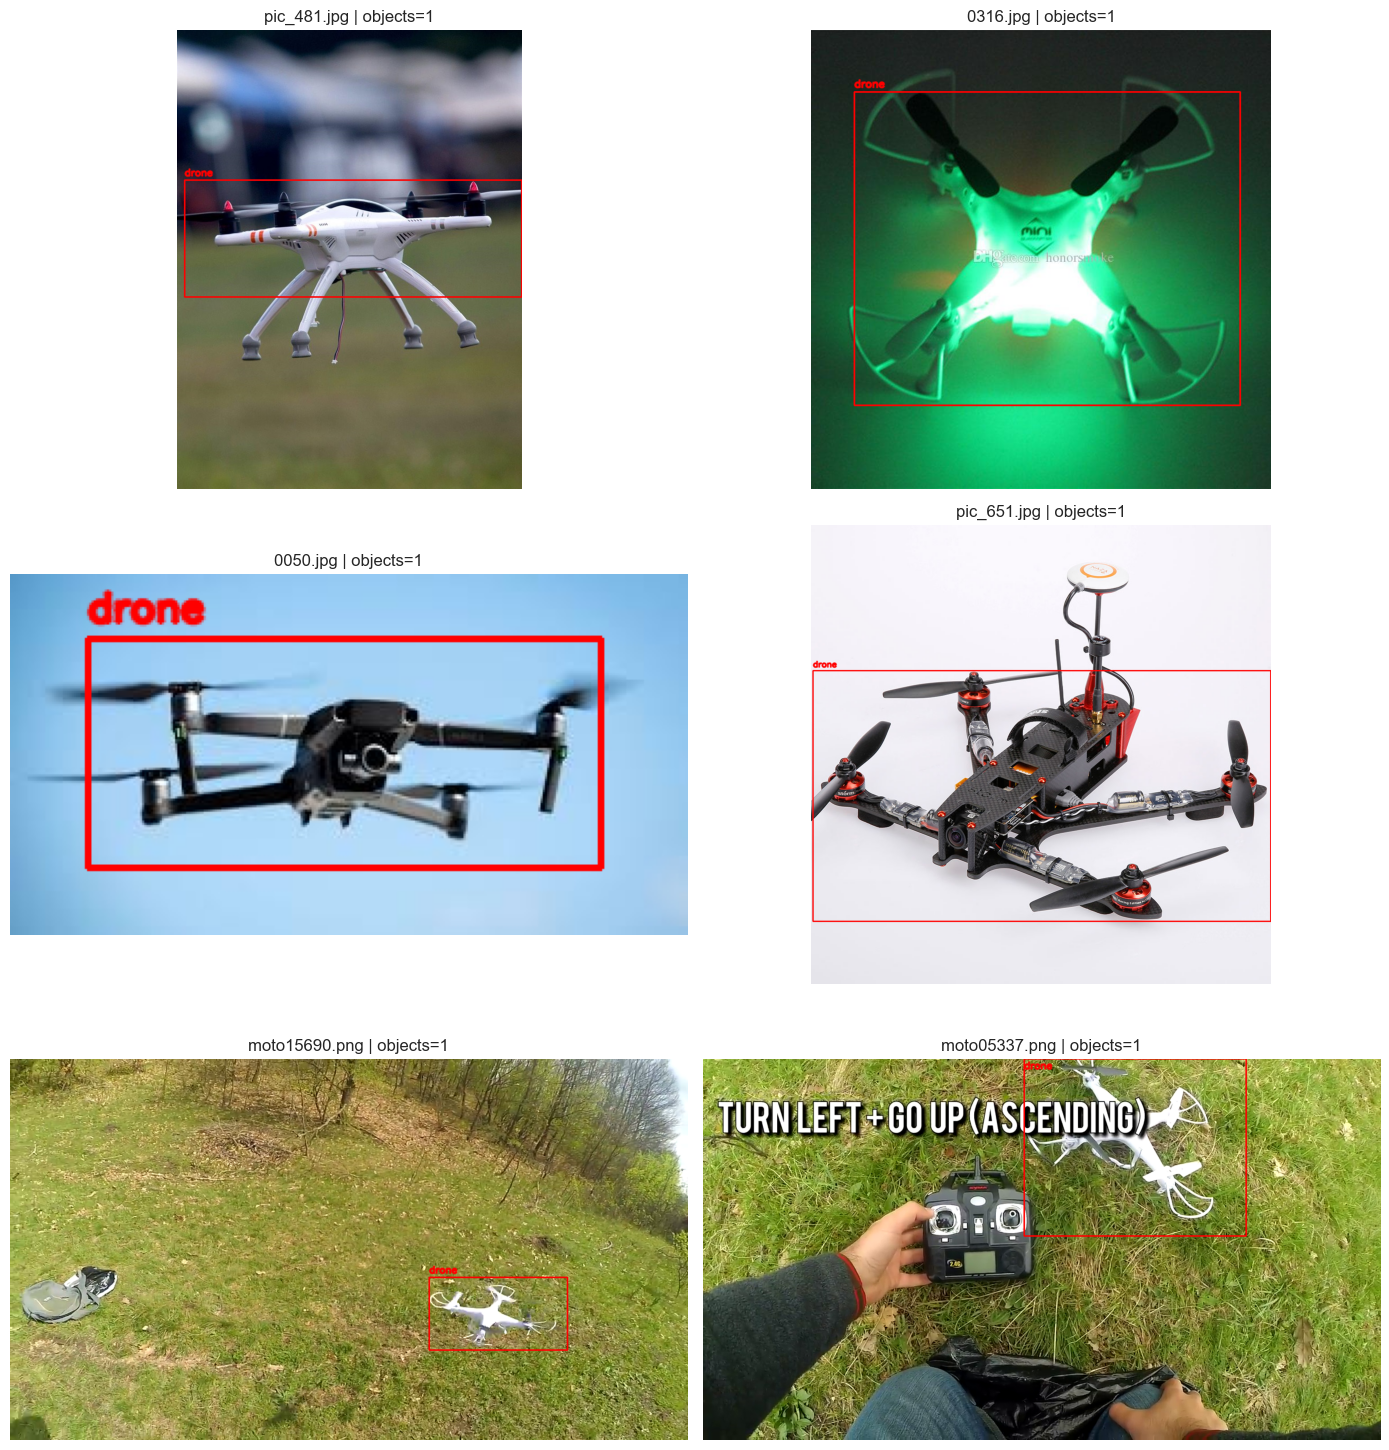

In [6]:
def draw_ground_truth_boxes(image_rgb, boxes, color=(255, 0, 0)):
    annotated = image_rgb.copy()
    image_height, image_width = annotated.shape[:2]
    for box in boxes:
        x1, y1, x2, y2 = yolo_to_xyxy(box, image_width, image_height)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color=color, thickness=2)
        cv2.putText(
            annotated,
            'drone',
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2,
            cv2.LINE_AA,
        )
    return annotated

def show_random_training_samples(num_samples=6, seed=SEED):
    train_images = list_images('train')
    sampled_images = random.Random(seed).sample(train_images, k=min(num_samples, len(train_images)))
    fig, axes = plt.subplots(math.ceil(len(sampled_images) / 2), 2, figsize=(14, 5 * math.ceil(len(sampled_images) / 2)))
    axes = np.array(axes).reshape(-1)

    for axis, image_path in zip(axes, sampled_images):
        image_rgb = read_image_rgb(image_path)
        label_path = label_path_for_image(image_path, 'train')
        boxes, _ = parse_yolo_label_file(label_path)
        annotated = draw_ground_truth_boxes(image_rgb, boxes, color=(255, 0, 0))
        axis.imshow(annotated)
        axis.set_title(f'{image_path.name} | objects={len(boxes)}')
        axis.axis('off')

    for axis in axes[len(sampled_images):]:
        axis.axis('off')

    plt.tight_layout()
    plt.show()

show_random_training_samples(num_samples=6)

## Preprocessing and Data Cleaning
This section validates YOLO annotations, checks image readability with OpenCV, confirms `dataset.yaml`, and provides an optional quarantine helper for corrupted samples.

In [7]:
BOUNDARY_EPSILON = 1e-3
invalid_label_records = []
unreadable_images = image_df.loc[~image_df['image_readable'], ['split', 'image_name', 'image_path']].copy()

for row in box_df.itertuples(index=False):
    checks = [
        ('class_id_must_be_zero', row.class_id == 0),
        ('x_center_range', -BOUNDARY_EPSILON <= row.x_center <= 1 + BOUNDARY_EPSILON),
        ('y_center_range', -BOUNDARY_EPSILON <= row.y_center <= 1 + BOUNDARY_EPSILON),
        ('width_range', 0 < row.width <= 1 + BOUNDARY_EPSILON),
        ('height_range', 0 < row.height <= 1 + BOUNDARY_EPSILON),
        ('left_boundary', row.x_min_norm >= -BOUNDARY_EPSILON),
        ('top_boundary', row.y_min_norm >= -BOUNDARY_EPSILON),
        ('right_boundary', row.x_max_norm <= 1 + BOUNDARY_EPSILON),
        ('bottom_boundary', row.y_max_norm <= 1 + BOUNDARY_EPSILON),
    ]

    for check_name, passed in checks:
        if not passed:
            invalid_label_records.append({
                'split': row.split,
                'image_name': row.image_name,
                'stem': row.stem,
                'line_number': row.line_number,
                'issue': check_name,
                'class_id': row.class_id,
                'x_center': row.x_center,
                'y_center': row.y_center,
                'width': row.width,
                'height': row.height,
            })

invalid_labels_df = pd.DataFrame(invalid_label_records)

def quarantine_samples(sample_stems, destination_dir=None):
    if destination_dir is None:
        destination_dir = DATA_DIR / 'quarantine'
    destination_dir.mkdir(parents=True, exist_ok=True)

    for split in SPLITS:
        split_destination = destination_dir / split
        (split_destination / 'images').mkdir(parents=True, exist_ok=True)
        (split_destination / 'labels').mkdir(parents=True, exist_ok=True)

        for stem in sample_stems:
            for candidate_image in image_dir(split).glob(f'{stem}.*'):
                shutil.move(str(candidate_image), str(split_destination / 'images' / candidate_image.name))
            candidate_label = label_dir(split) / f'{stem}.txt'
            if candidate_label.exists():
                shutil.move(str(candidate_label), str(split_destination / 'labels' / candidate_label.name))

    return destination_dir

print('dataset.yaml validation')
display(pd.DataFrame([dataset_yaml]))

print(f'Boundary tolerance used during validation: {BOUNDARY_EPSILON}')
print(f'Unreadable images: {len(unreadable_images)}')
if len(unreadable_images):
    display(unreadable_images.head())

print(f'Invalid YOLO label rows: {len(invalid_labels_df)}')
if len(invalid_labels_df):
    display(invalid_labels_df['issue'].value_counts().rename_axis('issue').reset_index(name='count'))
    display(invalid_labels_df.head(20))
else:
    print('All parsed YOLO label rows passed validation checks.')

if not parse_issues_df.empty:
    print(f'Parsing issues found: {len(parse_issues_df)}')
    display(parse_issues_df.head(20))

dataset.yaml validation


,path,train,val,test,names
0,d:/college/semester6/deep_learning/drone_detec...,train/images,val/images,test/images,{0: 'drone'}


Boundary tolerance used during validation: 0.001
Unreadable images: 0
Invalid YOLO label rows: 0
All parsed YOLO label rows passed validation checks.


## Data Augmentation Recommendations
Small drone detection benefits from moderate spatial augmentation and strong color augmentation without heavily distorting object geometry. The configuration below is a good starting point for Ultralytics training.

In [8]:
AUGMENTATION_CONFIG = {
    'imgsz': IMAGE_SIZE,
    'mosaic': 1.0,
    'scale': 0.5,
    'degrees': 5.0,
    'translate': 0.10,
    'hsv_h': 0.015,
    'hsv_s': 0.70,
    'hsv_v': 0.40,
    'fliplr': 0.50,
    'perspective': 0.0,
    'shear': 0.0,
}

augmentation_notes = pd.DataFrame(
    [
        {'setting': key, 'value': value}
        for key, value in AUGMENTATION_CONFIG.items()
    ]
 )

display(augmentation_notes)
display(Markdown(
    'Recommended practice: keep `imgsz` at 640 for the baseline, then repeat the best model with `imgsz=960` if recall on small drones needs improvement.'
))

,setting,value
0,imgsz,640.000
1,mosaic,1.000
2,scale,0.500
3,degrees,5.000
4,translate,0.100
5,hsv_h,0.015
6,hsv_s,0.700
7,hsv_v,0.400
8,fliplr,0.500
9,perspective,0.000


Recommended practice: keep `imgsz` at 640 for the baseline, then repeat the best model with `imgsz=960` if recall on small drones needs improvement.

## Model Training Plan
The notebook compares fast and stronger baselines on the same train/val/test split. The default training cell is guarded by a flag so you can inspect the notebook first, then enable training when ready.

In [16]:
import gc
import os

GPU_MEMORY_GB = (
    torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    if torch.cuda.is_available()
    else 0.0
)

MODEL_CATALOG = [
    {'model_name': 'yolo11n', 'weights': 'yolo11n.pt'},
    {'model_name': 'yolo11s', 'weights': 'yolo11s.pt'},
    {'model_name': 'yolov8n', 'weights': 'yolov8n.pt'},
    {'model_name': 'yolov8s', 'weights': 'yolov8s.pt'},
]

LOW_VRAM_MODE = torch.cuda.is_available() and GPU_MEMORY_GB <= 4.5
MODEL_BATCH_OVERRIDES = {
    'yolo11n': 2 if LOW_VRAM_MODE else (-1 if torch.cuda.is_available() else BATCH_SIZE),
    'yolo11s': 2 if LOW_VRAM_MODE else (-1 if torch.cuda.is_available() else BATCH_SIZE),
    'yolov8n': 2 if LOW_VRAM_MODE else (-1 if torch.cuda.is_available() else BATCH_SIZE),
    'yolov8s': 2 if LOW_VRAM_MODE else (-1 if torch.cuda.is_available() else BATCH_SIZE),
}
MODEL_IMGSZ_OVERRIDES = {
    'yolo11n': 512 if LOW_VRAM_MODE else IMAGE_SIZE,
    'yolo11s': 512 if LOW_VRAM_MODE else IMAGE_SIZE,
    'yolov8n': 512 if LOW_VRAM_MODE else IMAGE_SIZE,
    'yolov8s': 512 if LOW_VRAM_MODE else IMAGE_SIZE,
}

DEFAULT_TRAIN_MODEL_NAMES = (
    ['yolo11n']
    if LOW_VRAM_MODE
    else [config['model_name'] for config in MODEL_CATALOG]
    )
TRAIN_MODEL_NAMES = DEFAULT_TRAIN_MODEL_NAMES.copy()
RUN_TRAINING = True
USE_MLFLOW = MLFLOW_AVAILABLE
ENABLE_TRAINING_MLFLOW = False
trained_runs = []

def clear_training_memory():
    gc.collect()
    if not torch.cuda.is_available():
        return

    for cleanup in (torch.cuda.empty_cache, torch.cuda.ipc_collect):
        try:
            cleanup()
        except Exception as cleanup_error:
            print(f'CUDA cache cleanup skipped: {cleanup_error}')
            break

def train_single_model(model_name, weights, epochs=EPOCHS, imgsz=IMAGE_SIZE, batch=BATCH_SIZE, patience=PATIENCE):
    run_name = f'{PROJECT_NAME}_{model_name}_img{imgsz}_e{epochs}'
    model = YOLO(weights)
    train_augmentation_config = {key: value for key, value in AUGMENTATION_CONFIG.items() if key != 'imgsz'}
    effective_batch = MODEL_BATCH_OVERRIDES.get(model_name, batch)
    effective_imgsz = MODEL_IMGSZ_OVERRIDES.get(model_name, imgsz)

    if not ENABLE_TRAINING_MLFLOW:
        os.environ['MLFLOW_TRACKING_URI'] = ''
        os.environ['MLFLOW_EXPERIMENT_NAME'] = ''
        os.environ['MLFLOW_RUN'] = ''

    clear_training_memory()

    try:
        train_results = model.train(
            data=str(YAML_PATH),
            epochs=epochs,
            imgsz=effective_imgsz,
            batch=effective_batch,
            patience=patience,
            optimizer='auto',
            pretrained=True,
            project=str(RUNS_ROOT),
            name=run_name,
            exist_ok=True,
            device=DEVICE,
            workers=WORKERS,
            seed=SEED,
            verbose=True,
            **train_augmentation_config,
        )
    except RuntimeError as error:
        error_text = str(error)
        if 'out of memory' in error_text.lower() or 'acceleratorerror' in error_text.lower():
            raise RuntimeError(
                f'GPU memory was insufficient for {model_name} with imgsz={effective_imgsz} and batch={effective_batch}. '
                f'Restart the notebook kernel to clear the poisoned CUDA state, then rerun from Cell 3 through this cell. '
                f'If it still fails, keep yolo11n only and lower IMAGE_SIZE to 448. '
                f'Original error: {error_text}'
            ) from error
        raise
    finally:
        clear_training_memory()

    best_weights = RUNS_ROOT / run_name / 'weights' / 'best.pt'
    run_info = {
        'model_name': model_name,
        'weights': weights,
        'run_name': run_name,
        'batch_used': effective_batch,
        'imgsz_used': effective_imgsz,
        'best_weights': best_weights,
        'train_results': train_results,
    }

    return run_info

print(f'GPU memory detected: {GPU_MEMORY_GB:.2f} GB')
if LOW_VRAM_MODE:
    print('4 GB GPU detected: defaulting to yolo11n with imgsz=512 and batch=2 for the first stable run.')
display(pd.DataFrame(MODEL_CATALOG))

if RUN_TRAINING:
    for config in MODEL_CATALOG:
        if config['model_name'] in TRAIN_MODEL_NAMES:
            trained_runs.append(train_single_model(**config))
    display(pd.DataFrame(trained_runs)[['model_name', 'imgsz_used', 'batch_used', 'run_name', 'best_weights']])
else:
    print('Training is disabled by default. Set RUN_TRAINING = True to launch training runs.')
    display(pd.DataFrame(MODEL_CATALOG))

GPU memory detected: 4.00 GB
4 GB GPU detected: defaulting to yolo11n with imgsz=512 and batch=2 for the first stable run.


,model_name,weights
0,yolo11n,yolo11n.pt
1,yolo11s,yolo11s.pt
2,yolov8n,yolov8n.pt
3,yolov8s,yolov8s.pt


CUDA cache cleanup skipped: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Ultralytics 8.4.41  Python-3.12.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
CUDA cache cleanup skipped: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



RuntimeError: GPU memory was insufficient for yolo11n with imgsz=512 and batch=2. Restart the notebook kernel to clear the poisoned CUDA state, then rerun from Cell 3 through this cell. If it still fails, keep yolo11n only and lower IMAGE_SIZE to 448. Original error: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## Evaluation and Model Comparison
Recall is especially important for drone detection because missed drones are more costly than extra false positives. The following cells evaluate trained models on validation and test sets, then build a final comparison table sorted by quality and speed.

In [10]:
def discover_trained_weights():
    discovered = {}
    for config in MODEL_CATALOG:
        pattern = f'**/{PROJECT_NAME}_{config["model_name"]}_*/weights/best.pt'
        matches = sorted(RUNS_ROOT.glob(pattern), key=lambda path: path.stat().st_mtime, reverse=True)
        if matches:
            discovered[config['model_name']] = matches[0]
    return discovered

def model_parameter_count(model):
    try:
        return int(sum(parameter.numel() for parameter in model.model.parameters()))
    except Exception:
        return np.nan

def evaluate_model(weights_path: Path, split='val', batch=BATCH_SIZE):
    model = YOLO(str(weights_path))
    metrics = model.val(
        data=str(YAML_PATH),
        split=split,
        imgsz=IMAGE_SIZE,
        batch=batch,
        device=DEVICE,
        workers=WORKERS,
        verbose=False,
    )

    precision = float(metrics.box.mp)
    recall = float(metrics.box.mr)
    ap50 = float(metrics.box.map50)
    map50_95 = float(metrics.box.map)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    inference_ms = float(metrics.speed.get('inference', np.nan)) if hasattr(metrics, 'speed') else np.nan
    fps = 1000.0 / inference_ms if inference_ms and not np.isnan(inference_ms) else np.nan
    size_mb = weights_path.stat().st_size / (1024 ** 2)

    result_row = {
        'model_name': weights_path.parent.parent.parent.name.replace(f'{PROJECT_NAME}_', ''),
        'split': split,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'AP50': ap50,
        'mAP50_95': map50_95,
        'inference_ms': inference_ms,
        'FPS': fps,
        'model_size_MB': size_mb,
        'parameters': model_parameter_count(model),
        'weights_path': str(weights_path),
    }

    if USE_MLFLOW:
        with mlflow.start_run(run_name=f'eval_{weights_path.stem}_{split}', nested=False):
            mlflow.log_params({
                'model_name': result_row['model_name'],
                'split': split,
                'imgsz': IMAGE_SIZE,
                'batch': batch,
            })
            mlflow.log_metrics({
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'AP50': ap50,
                'mAP50_95': map50_95,
                'inference_ms': inference_ms,
                'FPS': fps,
            })

    return result_row

trained_weight_map = discover_trained_weights()
if trained_weight_map:
    val_results_df = pd.DataFrame([evaluate_model(path, split='val') for path in trained_weight_map.values()])
    test_results_df = pd.DataFrame([evaluate_model(path, split='test') for path in trained_weight_map.values()])

    comparison_df = (
        test_results_df[['model_name', 'precision', 'recall', 'f1', 'AP50', 'mAP50_95', 'inference_ms', 'FPS', 'model_size_MB', 'parameters']]
        .sort_values(by=['mAP50_95', 'recall', 'FPS'], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    display(Markdown('### Validation Metrics'))
    display(val_results_df.sort_values(by='mAP50_95', ascending=False))
    display(Markdown('### Test Metrics'))
    display(test_results_df.sort_values(by='mAP50_95', ascending=False))
    display(Markdown('### Final Model Comparison'))
    display(comparison_df)

    best_model = comparison_df.iloc[0]
    display(Markdown(
        f"**Recommended model:** `{best_model['model_name']}` because it gives the best overall balance of mAP@50-95, recall, and FPS on the test split."
    ))
else:
    comparison_df = pd.DataFrame()
    print('No trained weights were discovered yet. Run the training cell first, then rerun this evaluation section.')

Ultralytics 8.4.41  Python-3.12.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## Prediction Demo
The `detect_drones` function loads a trained model, runs inference, draws red boxes and confidence scores, saves the result, and displays the output image.

In [ ]:
def detect_drones(image_path, model_path, conf_threshold=CONF_THRESHOLD):
    image_path = Path(image_path)
    model_path = Path(model_path)
    model = YOLO(str(model_path))

    result = model.predict(
        source=str(image_path),
        conf=conf_threshold,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        verbose=False,
    )[0]

    image_bgr = cv2.imread(str(image_path))
    output_bgr = image_bgr.copy()
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        print('No drone detected')
    else:
        xyxy_boxes = boxes.xyxy.cpu().numpy()
        confidences = boxes.conf.cpu().numpy()
        for xyxy, confidence in zip(xyxy_boxes, confidences):
            x1, y1, x2, y2 = map(int, xyxy.tolist())
            cv2.rectangle(output_bgr, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(
                output_bgr,
                f'drone {confidence:.2f}',
                (x1, max(20, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 0, 255),
                2,
                cv2.LINE_AA,
            )

    output_path = PREDICTION_DIR / f'{image_path.stem}_prediction.jpg'
    cv2.imwrite(str(output_path), output_bgr)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(output_bgr, cv2.COLOR_BGR2RGB))
    plt.title(f'Prediction: {image_path.name}')
    plt.axis('off')
    plt.show()

    return output_path, result

DEMO_IMAGE = image_df.loc[image_df['split'] == 'test', 'image_path'].iloc[0] if not image_df.empty else None
DEMO_MODEL = next(iter(trained_weight_map.values())) if 'trained_weight_map' in globals() and trained_weight_map else None

if DEMO_IMAGE and DEMO_MODEL:
    demo_output_path, _ = detect_drones(DEMO_IMAGE, DEMO_MODEL, conf_threshold=CONF_THRESHOLD)
    print(f'Saved prediction to: {demo_output_path}')
else:
    print('Prediction demo is ready. Train at least one model first, then rerun this cell.')

Prediction demo is ready. Train at least one model first, then rerun this cell.


## Error Analysis
This section looks for correct detections, missed drones, false positives, and low-confidence detections. It also closes with practical recommendations for improving recall and overall robustness.

In [ ]:
def iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter_area
    return inter_area / union if union else 0.0

def ground_truth_boxes_for_image(image_path: Path, split: str):
    image_rgb = read_image_rgb(image_path)
    if image_rgb is None:
        return []
    image_height, image_width = image_rgb.shape[:2]
    label_path = label_path_for_image(image_path, split)
    boxes, _ = parse_yolo_label_file(label_path)
    return [yolo_to_xyxy(box, image_width, image_height) for box in boxes]

def classify_prediction_case(model, image_path: Path, split: str, conf_threshold=CONF_THRESHOLD, iou_threshold=0.5):
    predictions = model.predict(source=str(image_path), conf=conf_threshold, imgsz=IMAGE_SIZE, device=DEVICE, verbose=False)[0]
    predicted_boxes = []
    predicted_confidences = []
    if predictions.boxes is not None and len(predictions.boxes) > 0:
        predicted_boxes = [tuple(map(float, box)) for box in predictions.boxes.xyxy.cpu().numpy().tolist()]
        predicted_confidences = predictions.boxes.conf.cpu().numpy().tolist()

    gt_boxes = ground_truth_boxes_for_image(image_path, split)
    matched_gt = set()
    matched_predictions = set()

    for pred_index, pred_box in enumerate(predicted_boxes):
        for gt_index, gt_box in enumerate(gt_boxes):
            if gt_index in matched_gt:
                continue
            if iou_xyxy(pred_box, gt_box) >= iou_threshold:
                matched_gt.add(gt_index)
                matched_predictions.add(pred_index)
                break

    missed = len(gt_boxes) - len(matched_gt)
    false_positives = len(predicted_boxes) - len(matched_predictions)
    low_conf = any(confidence < 0.40 for confidence in predicted_confidences)

    if len(gt_boxes) > 0 and missed == 0 and false_positives == 0:
        category = 'correct detection'
    elif missed > 0:
        category = 'missed drones'
    elif false_positives > 0:
        category = 'false positives'
    elif low_conf:
        category = 'low-confidence detections'
    else:
        category = 'uncategorized'

    return {
        'image_path': str(image_path),
        'category': category,
        'ground_truth_count': len(gt_boxes),
        'prediction_count': len(predicted_boxes),
        'missed': missed,
        'false_positives': false_positives,
        'max_confidence': max(predicted_confidences) if predicted_confidences else 0.0,
    }

def collect_error_analysis_examples(model_path, split='test', limit=60):
    model = YOLO(str(model_path))
    examples = []
    for image_path in tqdm(list_images(split)[:limit], desc='Error analysis', leave=False):
        examples.append(classify_prediction_case(model, image_path, split=split))
    return pd.DataFrame(examples)

if DEMO_MODEL:
    error_analysis_df = collect_error_analysis_examples(DEMO_MODEL, split='test', limit=60)
    display(error_analysis_df['category'].value_counts().rename_axis('category').reset_index(name='count'))
    display(error_analysis_df.head(10))
else:
    error_analysis_df = pd.DataFrame()
    print('Error analysis is ready. Train at least one model first, then rerun this cell.')

display(Markdown("""
### How to Improve Drone Detection
- Add more images and especially more hard negative examples.
- Add more small-drone and far-distance examples to improve recall.
- Increase `imgsz` from 640 to 960 for the best candidate model.
- Improve label quality for tiny or partially visible drones.
- Try stronger backbones such as YOLO11s or YOLO11m if GPU memory allows.
- Tune the confidence threshold after inspecting false negatives and false positives.
"""))

Error analysis is ready. Train at least one model first, then rerun this cell.



### How to Improve Drone Detection
- Add more images and especially more hard negative examples.
- Add more small-drone and far-distance examples to improve recall.
- Increase `imgsz` from 640 to 960 for the best candidate model.
- Improve label quality for tiny or partially visible drones.
- Try stronger backbones such as YOLO11s or YOLO11m if GPU memory allows.
- Tune the confidence threshold after inspecting false negatives and false positives.


## Practical Notes
- Use the existing `dl_venv` environment for this notebook; no new virtual environment is required.
- Start with `yolo11n` or `yolov8n` for a quick baseline, then scale up to `yolo11s` or `yolov8s` for accuracy.
- Because recall matters most for drone detection, prefer the model that misses the fewest drones even if it is slightly slower.
- The notebook intentionally omits DVC setup because you said it can be ignored for this project.